In [1]:
import sys;from pathlib import Path;sys.path.insert(0, str(Path().resolve()))

import torch
import matplotlib.pyplot as plt
import random
from PIL import Image
from IPython.display import display, clear_output

from transformers import CLIPTokenizer
from module import model_loader, pipeline

from trainer.dataset import create_dataloader, ImageTextDataset
from trainer.train_vae import VAETrainer, compute_vae_scaling_factor
from trainer.train_diffusion import DiffusionTrainer

torch.set_float32_matmul_precision('high')
DEVICE = "cuda" if torch.cuda.is_available() else 'cpu'
DTYPE = torch.bfloat16 if DEVICE=="cuda" else torch.bfloat32
DEVICE, DTYPE

('cuda', torch.bfloat16)

## VAE Trainning

### Train

🔄 Initializing VAE_Encoder and VAE_Decoder...
✅ Initialization finished!
🔄 Initializing encoder...
🔄 Loading model/base-v1-5-pruned-emaonly.safetensors for encoder...
✅ Finished!
🔄 Initializing decoder...
🔄 Loading model/base-v1-5-pruned-emaonly.safetensors for decoder...
✅ Finished!
🔄 Frozen encoder...
📂 Loading dataset...
📂 Loaded 1000 image-text pairs from dataset/minecraft-preview/


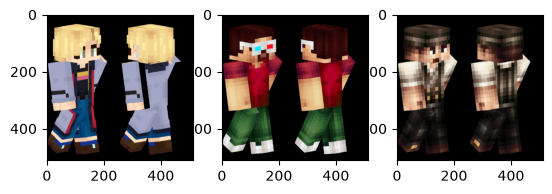

Caption 1: The 13th Doctor from the British television series Doctor Who.
Caption 2: A male wearing 3D glasses.
Caption 3: Gangster from the 1950s.
🔄 Initializing Loss, optimizer and scheduler...
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /root/miniconda3/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth
✅ Initialization finished!

📊 Configuration:
   DATASET DIRECTORY:    dataset/minecraft-preview/
   DATASET SIZE:         1000
   CHECKPOINT DIRECTORY: checkpoint
   PRETRAIN MODEL PATH:  model/base-v1-5-pruned-emaonly.safetensors
   IMAGE SIZE:           512x512
   BATCH SIZE:           4
   NUM WORKERS:          16
   LEARNING RATE:        0.0001
   TOTAL EPOCHS:         1
   LPIPS WEIGHT:         0.1
   KL WEIGHT:            1e-06
   SAVE INTERVAL:        1
   DEVICE:               cuda
✅ **All initialization is ready, start training using trainer.train()**


In [2]:
trainer = VAETrainer('dataset/minecraft-preview/', 
                     output_dir="checkpoint/",
                     from_pretrain = "model/base-v1-5-pruned-emaonly.safetensors",
                     frozen_weights = "encoder",
                     image_size = 512,
                     batch_size = 4,
                     num_workers = 16,
                     learning_rate = 1e-4,
                     num_epochs = 1,
                     lpips_weight = 0.1,
                     kl_weight = 1e-6,
                     scaling_factor=1.0,
                     save_every = 1,
                     device=DEVICE)

🚀 Starting VAE training for 1 epochs...


Epoch 1/1: 100%|██████████| 250/250 [01:41<00:00,  2.46it/s, total=0.5625, recon=0.0131, kl=547828.4375]



📊 Epoch 1 Summary:
   Total: 0.536620
   Recon: 0.016488
   LPIPS: 0.022892
   KL:    517842.616125
   LR:    1.00e-06


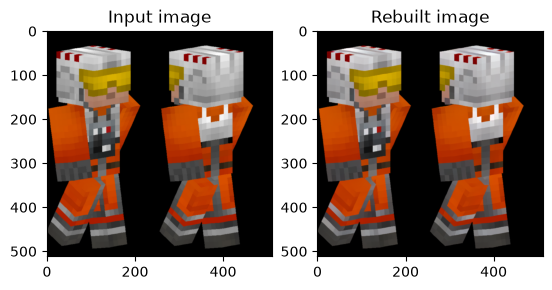

💾 Checkpoint saved: checkpoint/vae_epoch_1.pt
✅ VAE training complete!


In [3]:
trainer.train()

### Eval

In [2]:
# Initialize dataset and vae models
dataset = ImageTextDataset("dataset/minecraft-preview/", image_size=512)
encoder = model_loader.get_model(name='encoder', ckp_path="checkpoint/vae_epoch_1.pt", device=DEVICE, dtype=DTYPE).eval()
decoder = model_loader.get_model(name='decoder', ckp_path="checkpoint/vae_epoch_1.pt", device=DEVICE, dtype=DTYPE).eval()

📂 Loaded 1000 image-text pairs from dataset/minecraft-preview/
🔄 Initializing encoder...
🔄 Loading checkpoint/vae_epoch_1.pt for encoder...
✅ Finished!
🔄 Initializing decoder...
🔄 Loading checkpoint/vae_epoch_1.pt for decoder...
✅ Finished!


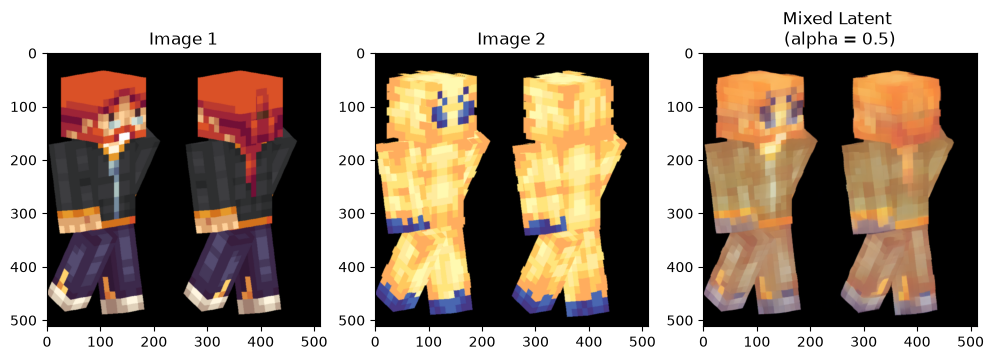

In [3]:
# Randomly select two images
idx1 = random.randint(0, len(dataset))
idx2 = random.randint(0, len(dataset))
img1 = dataset[idx1]['image'].unsqueeze(0).to(device=DEVICE, dtype=DTYPE)
img2 = dataset[idx2]['image'].unsqueeze(0).to(device=DEVICE, dtype=DTYPE)
noise = torch.randn(1, 4, 512 // 8, 512 // 8, device=DEVICE, dtype=DTYPE)

# Mix the latent space of the two using alpha as the ratio
alpha = 0.5
latent1 = encoder(img1, noise)
latent2 = encoder(img2, noise)
latent = (1 - alpha) * latent1 + alpha * latent2
rebuilt_img = decoder(latent)

# Display
post_process = lambda img: ((img.detach().squeeze(0).cpu().permute(1, 2, 0).clamp(-1, 1) + 1) / 2 * 255).byte()
fig, axs = plt.subplots(1, 3, figsize=(12, 5))
axs[0].imshow(post_process(img1))
axs[1].imshow(post_process(img2))
axs[2].imshow(post_process(rebuilt_img))
axs[0].set_title('Image 1')
axs[1].set_title('Image 2')
axs[2].set_title(f"Mixed Latent \n(alpha = {alpha})")
plt.show()

## Diffusion Training

### Train

🔄 Initializing CLIPTokenizer...
✅ Finished!
🔄 Initializing encoder...
🔄 Loading checkpoint/vae_epoch_1.pt for encoder...
✅ Finished!
🔄 Initializing decoder...
🔄 Loading checkpoint/vae_epoch_1.pt for decoder...
✅ Finished!
🔄 Initializing clip...
🔄 Loading model/base-v1-5-pruned-emaonly.safetensors for clip...
✅ Finished!
🔄 Initializing diffusion...
🔄 Loading model/base-v1-5-pruned-emaonly.safetensors for diffusion...
✅ Finished!
🔄 Frozen encoder, decoder and clip...
✅ Finished!
📂 Loading dataset...
📂 Loaded 1000 image-text pairs from dataset/minecraft-preview/


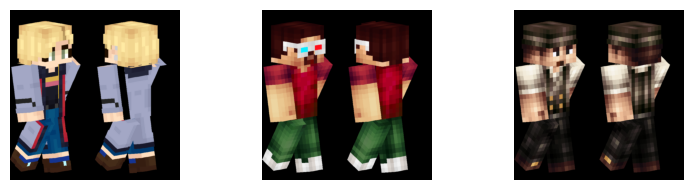

Caption 1: The 13th Doctor from the British television series Doctor Who.
Tokenized 1: tensor([49406,   518,   272,   274,   640,  5547,   633,   518,  3504,  8608,
         1857,  5547,   822,   269, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407])
Caption 2: A male wearing 3D glasses.
Tokenized 2: tensor([49406,   320,  2801,  3309,   274,   323,  6116,   269, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49

In [2]:
diffusion_trainer = DiffusionTrainer(
    data_dir='dataset/minecraft-preview/',
    output_dir='checkpoint/',
    vae_ckp='checkpoint/vae_epoch_1.pt',
    clip_ckp='model/base-v1-5-pruned-emaonly.safetensors',
    diffusion_ckp='model/base-v1-5-pruned-emaonly.safetensors',
    tokenizer_dir='tokenizer',
    image_size=512,
    batch_size=8,
    num_workers=16,
    learning_rate=1e-5,
    num_epochs=2,
    save_every=2,
    device=DEVICE,
    scaling_factor=0.18215,
)

🚀 Starting DiffusionModel training for 2 epochs...


Epoch 1/2: 100%|██████████| 125/125 [00:50<00:00,  2.48it/s, loss=0.1142]



📊 Epoch 1 summary：
   Average Loss: 0.057893
   LR:           5.05e-06


Sampling: 100%|██████████| 50/50 [00:01<00:00, 25.38step/s]


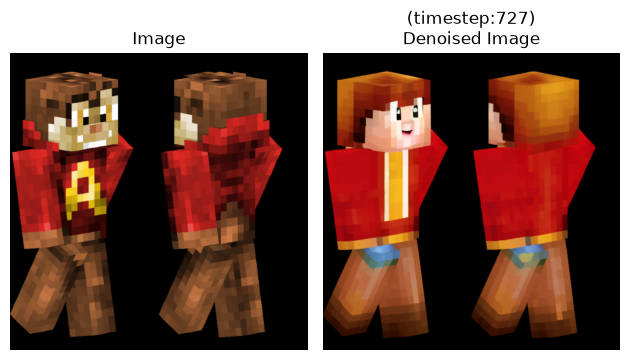

Epoch 2/2: 100%|██████████| 125/125 [00:49<00:00,  2.53it/s, loss=0.0680]



📊 Epoch 2 summary：
   Average Loss: 0.051749
   LR:           1.00e-07


Sampling: 100%|██████████| 60/60 [00:02<00:00, 25.83step/s]


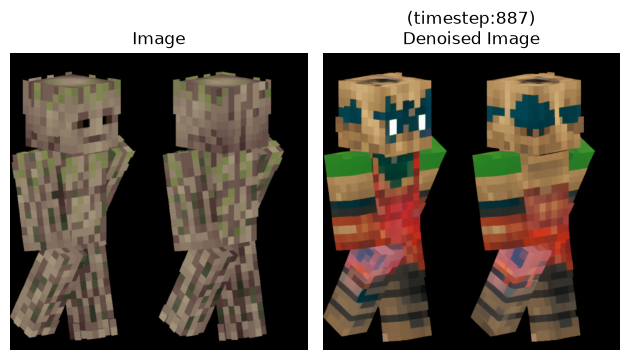

💾 Checkpoint saved: checkpoint/diffusion_epoch_2.pt
✅ Training finished!


In [3]:
diffusion_trainer.train()

### Eval

In [2]:
tokenizer = CLIPTokenizer("tokenizer/vocab.json", "tokenizer/merges.txt")
models = {
    "encoder": model_loader.get_model(name='encoder', ckp_path="checkpoint/vae_epoch_1.pt", device=DEVICE, dtype=DTYPE).eval(),
    "decoder": model_loader.get_model(name='decoder', ckp_path="checkpoint/vae_epoch_1.pt", device=DEVICE, dtype=DTYPE).eval(),
    "clip": model_loader.get_model(name='clip', ckp_path="model/base-v1-5-pruned-emaonly.safetensors", device=DEVICE, dtype=DTYPE).eval(),
    "diffusion": model_loader.get_model(name='diffusion', ckp_path="checkpoint/diffusion_epoch_2.pt", device=DEVICE, dtype=DTYPE).eval(),
}

🔄 Initializing encoder...
🔄 Loading checkpoint/vae_epoch_1.pt for encoder...
✅ Finished!
🔄 Initializing decoder...
🔄 Loading checkpoint/vae_epoch_1.pt for decoder...
✅ Finished!
🔄 Initializing clip...
🔄 Loading model/base-v1-5-pruned-emaonly.safetensors for clip...
✅ Finished!
🔄 Initializing diffusion...
🔄 Loading checkpoint/diffusion_epoch_2.pt for diffusion...
✅ Finished!


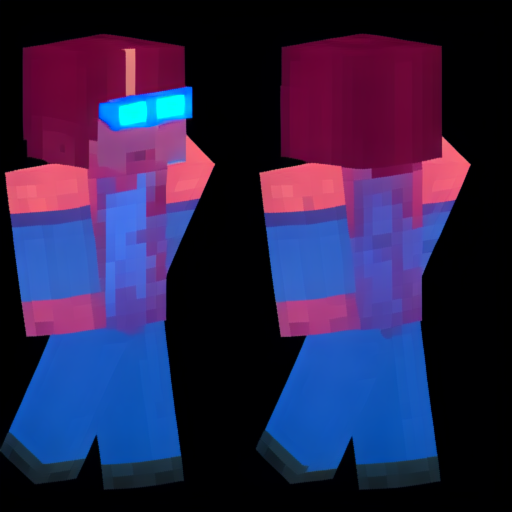

Sampling: 100%|██████████| 67/67 [00:09<00:00,  7.42step/s]


In [7]:
##### GENERATION LOOP
#input_image = Image.open('dataset/minecraft-preview/images/3dglasses-preview.png').convert("RGB")
input_image = None
generator = pipeline.generate(
    prompt="A male wearing 3D glasses.",
    uncond_prompt="",
    img_width=512,
    img_height=512,
    input_image=input_image,
    strength=0.95,
    do_cfg=True,
    cfg_scale=8.5,
    sampler_name="ddpm",
    n_inference_steps=64,
    num_training_steps=1000,
    models=models,
    seed=random.randint(0, int(1e8)),
    device=DEVICE,
    dtype=DTYPE,
    tokenizer=tokenizer,
    ddim_eta=0.2,
    decode_interval=6,
    scaling_factor=0.18215
)
for output_image in generator:
    pil_img = Image.fromarray(output_image[0])
    clear_output(wait=True)
    display(pil_img)